In [2]:
import os
from pathlib import Path
import pickle
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dropout, Dense
from tensorflow.keras.models import load_model

# Preprocessing

## Create label mapping

In [ ]:
data_dir = Path("/content/drive/MyDrive/Lip Landmark Dataset/landmark_dataset")

train_data_dir = data_dir / "train"
words = sorted([f.name for f in train_data_dir.iterdir() if f.is_dir()])
word_to_idx = {word: i for i, word in enumerate(words)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

print(word_to_idx)

{'a': 0, 'again': 1, 'at': 2, 'b': 3, 'bin': 4, 'blue': 5, 'by': 6, 'c': 7, 'd': 8, 'e': 9, 'eight': 10, 'f': 11, 'five': 12, 'four': 13, 'g': 14, 'green': 15, 'h': 16, 'i': 17, 'in': 18, 'j': 19, 'k': 20, 'l': 21, 'lay': 22, 'm': 23, 'n': 24, 'nine': 25, 'now': 26, 'o': 27, 'one': 28, 'p': 29, 'place': 30, 'please': 31, 'q': 32, 'r': 33, 'red': 34, 's': 35, 'set': 36, 'seven': 37, 'six': 38, 'soon': 39, 't': 40, 'three': 41, 'two': 42, 'u': 43, 'v': 44, 'white': 45, 'with': 46, 'x': 47, 'y': 48, 'z': 49, 'zero': 50}


## Split dataset into input and output

In [8]:
x = []
y = []

for word in tqdm(words):
    word_dir = Path(train_data_dir) / word

    for file in word_dir.iterdir():
        arr = np.load(file)
        x.append(arr)
        y.append(word_to_idx[word])

x = np.array(x)   # (N, 30, 80)
y = np.array(y)   # (N,)

In [4]:
save_path_x = Path(data_dir) / "x.npy"
save_path_y = Path(data_dir) / "y.npy"
# np.save(save_path_x, x)
# np.save(save_path_y, y)

In [5]:
x = np.load(save_path_x)
y = np.load(save_path_y)

In [6]:
x.shape, y.shape

((12000, 30, 80), (12000,))

## Train-Test Split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

In [8]:
x_train.shape, x_test.shape

((9600, 30, 80), (2400, 30, 80))

In [9]:
y_train.shape, y_test.shape

((9600,), (2400,))

## Dataset level Normalization
Different speakers have slightly different lip sizes. For even feature distribution, normalize across dataset

In [14]:
mean = x_train.mean()
std = x_train.std() + 1e-8

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# Model Creation

In [15]:
model = Sequential([
    Input(shape=(30, 80)),
    Masking(mask_value=0.0),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(words), activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       107,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 51)             │         3,315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,891 (640.20 KB)

 Trainable params: 163,891 (640.20 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [18]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1256 - loss: 3.2035 - val_accuracy: 0.1633 - val_loss: 2.9097
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.1617 - loss: 2.9224 - val_accuracy: 0.2237 - val_loss: 2.7643
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2644 - loss: 2.5768 - val_accuracy: 0.2842 - val_loss: 2.4218
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3398 - loss: 2.2459 - val_accuracy: 0.3983 - val_loss: 2.0474
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4002 - loss: 2.0015 - val_accuracy: 0.4650 - val_loss: 1.8235
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4468 - loss: 1.8511 - val_accuracy: 0.4988 - val_loss: 1.7151
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4882 - loss: 1.7063 - val_accuracy: 0.4950 - val_loss: 1.7137
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5178 - loss: 1.6272 - val_accur

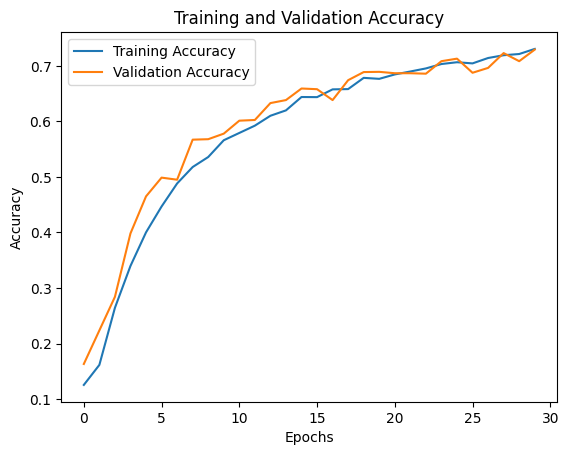

In [23]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add labels and legend
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Saving the model

In [24]:
model.save("lip_reading_model.h5")

In [26]:
with open("label_map.pkl", "wb") as f:
    pickle.dump(word_to_idx, f)

with open("norm.pkl", "wb") as f:
    pickle.dump((mean, std), f)

# Load model for inference

In [34]:
model = load_model("lip_reading_model.h5")

with open("label_map.pkl", "rb") as f:
    word_to_idx = pickle.load(f)

idx_to_word = {v: k for k, v in word_to_idx.items()}

with open("norm.pkl", "rb") as f:
    mean, std = pickle.load(f)